# Working with Langchain and LangGraph
- Models/Chatmodels
- Prompt Templates
- Parsers
- Tools


In [ ]:
!pip install langchain langchain_openai langchain_core langchain_community --quiet

OPENAI_API_VERSION="2025-04-01-preview"

In [2]:
# model
from langchain.chat_models import init_chat_model
model = init_chat_model("azure_openai:gpt-4o-mini")
output = model.invoke("Tell me a joke on laptop.")
print(output.content)

Why did the laptop break up with the smartphone?

Because it couldn't handle the constant notifications!


In [1]:
# prompt templates
from langchain_core.prompts import ChatPromptTemplate
prompt_temp = ChatPromptTemplate([("system","You are an expert translator, translate to {language}"),
                                  ("user","Translate: {text}")])
prompt_temp

PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


ChatPromptTemplate(input_variables=['language', 'text'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=['language'], input_types={}, partial_variables={}, template='You are an expert translator, translate to {language}'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['text'], input_types={}, partial_variables={}, template='Translate: {text}'), additional_kwargs={})])

In [3]:
prompt_temp.invoke({"language":"hindi","text":"Hello Good Morning"})

ChatPromptValue(messages=[SystemMessage(content='You are an expert translator, translate to hindi', additional_kwargs={}, response_metadata={}), HumanMessage(content='Translate: Hello Good Morning', additional_kwargs={}, response_metadata={})])

In [4]:
from langchain_core.output_parsers import StrOutputParser
parser = StrOutputParser()

In [5]:
model.invoke(prompt_temp.invoke({"language":"hindi","text":"Hello Good Morning"}))

AIMessage(content='नमस्ते, शुभ प्रभात', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 25, 'total_tokens': 34, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_eb37e061ec', 'id': 'chatcmpl-DHkEAiXlqiMWcJFstqbP74qAS59MJ', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'filtered': False, 'detected': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'stop', 'logprobs': None, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'protec

In [6]:
parser.invoke(model.invoke(prompt_temp.invoke({"language":"hindi","text":"Hello Good Morning"})))

'नमस्ते, शुभ प्रभात।'

In [7]:
# implementing a simple chain using LCEL
chain = prompt_temp | model | parser
chain.invoke({"language":"tamil","text":"Hello, Good Morning!"})


'வணக்கம், காலை வணக்கம்!'

## Static Workflow Design with LangGraph

In [8]:
# 1. Data model
from typing import TypedDict
# from pydantic import ..

class mystate(TypedDict):
    lang:str
    input_text:str
    answer:str

In [9]:
# node - translation node
def translation(state:mystate)->mystate:
    prompt_temp = ChatPromptTemplate([("system","You are an expert translator, translate to {language}"),
                                  ("user","Translate: {text}")])
    model = init_chat_model('azure_openai:gpt-4o-mini')
    parser = StrOutputParser()

    translation = prompt_temp | model | parser
    response = translation.invoke({"language":state['lang'],'text':state['input_text']})
    return {'answer':response}

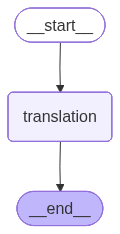

In [10]:
# create a graph
from langgraph.graph import StateGraph,START,END
graph_builder = StateGraph(mystate)
graph_builder.add_node('translation',translation)
graph_builder.add_edge(START,'translation')
graph_builder.add_edge('translation',END)

graph = graph_builder.compile()
graph

In [11]:
graph.invoke({"lang":'french','input_text':'How are you?'})

{'lang': 'french', 'input_text': 'How are you?', 'answer': 'Comment ça va ?'}